### =============================================================================
###  SnapSquad — Face Embedding Extraction & Model Comparison
###  Notebook: 2_face_embeddings.ipynb
###
###  Sections:
###    A. Quick Exploration (cells 1-4)  — FaceAnalysis defaults (buffalo_l)
###    B. Model Comparison  (cells 5-12) — MobileFaceNet vs R50 vs R100
###    C. Save Final Output (cell 13)    — mobilefacenet_embeddings.json
###
###  Final output used by notebook 3: mobilefacenet_embeddings.json
###  (MobileFaceNet w600k_mbf.onnx — 512-d, 4MB, chosen per architecture doc)
### =============================================================================

In [ ]:
import cv2
import numpy as np
import insightface
from insightface.app import FaceAnalysis
import matplotlib.pyplot as plt
import json
import os

# ── Section A: Quick exploration with FaceAnalysis defaults (buffalo_l) ──────
# NOTE: This uses the default buffalo_l recognition model, NOT MobileFaceNet.
# The proper comparison with MobileFaceNet is in Section B below (cells 5+).

app = FaceAnalysis(
    allowed_modules=['detection', 'recognition'],
    providers=['CPUExecutionProvider']
)
app.prepare(ctx_id=0, det_size=(640, 640))

# Override detector with our SCRFD-10G at thresh 0.5 (per architecture doc)
detector = insightface.model_zoo.get_model(
    r'models\scrfd_10g_bnkps.onnx',
    providers=['CPUExecutionProvider']
)
detector.prepare(ctx_id=0, input_size=(640, 640), det_thresh=0.5)
app.det_model = detector

print("Models loaded successfully")
print(f"Recognition model: {app.models}")
print("⚠️  Note: uses buffalo_l default recognition — see Section B for MobileFaceNet")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: C:\Users\kvpra/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: C:\Users\kvpra/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\kvpra/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: C:\Users\kvpra/.insightface\models\buffalo_l\genderage.onnx genderage
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\kvpra/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Applied providers: ['CPUExecutionProvider'], with

In [2]:
# ── Extract embeddings from all test images ───────────────────────────────────
test_folder = "test_images"
images = [f for f in os.listdir(test_folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]

embeddings_data = []  # will save to JSON at the end

for img_file in images:
    img = cv2.imread(os.path.join(test_folder, img_file))
    faces = app.get(img)
    
    print(f"\n{img_file} → {len(faces)} face(s) detected")
    
    for i, face in enumerate(faces):
        emb = face.normed_embedding  # 512-dim L2 normalised vector
        
        embeddings_data.append({
            "image": img_file,
            "face_index": i,
            "bbox": face.bbox.tolist(),
            "det_score": float(face.det_score),
            "embedding": emb.tolist()   # 512 floats
        })
        
        print(f"  Face {i}: confidence={face.det_score:.2f}  embedding shape={emb.shape}  norm={np.linalg.norm(emb):.4f}")

print(f"\nTotal faces extracted: {len(embeddings_data)}")

# ── Save to JSON ──────────────────────────────────────────────────────────────
with open("embeddings.json", "w") as f:
    json.dump(embeddings_data, f, indent=2)

print("Saved to embeddings.json")

C:\Users\kvpra\OneDrive\Desktop\snapsquad-app\Notebooks\venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)



2.jpeg → 5 face(s) detected
  Face 0: confidence=0.90  embedding shape=(512,)  norm=1.0000
  Face 1: confidence=0.88  embedding shape=(512,)  norm=1.0000
  Face 2: confidence=0.87  embedding shape=(512,)  norm=1.0000
  Face 3: confidence=0.87  embedding shape=(512,)  norm=1.0000
  Face 4: confidence=0.86  embedding shape=(512,)  norm=1.0000

3.jpeg → 5 face(s) detected
  Face 0: confidence=0.89  embedding shape=(512,)  norm=1.0000
  Face 1: confidence=0.86  embedding shape=(512,)  norm=1.0000
  Face 2: confidence=0.84  embedding shape=(512,)  norm=1.0000
  Face 3: confidence=0.82  embedding shape=(512,)  norm=1.0000
  Face 4: confidence=0.81  embedding shape=(512,)  norm=1.0000

aksajkca.jpeg → 0 face(s) detected

DSC05300.JPG → 2 face(s) detected
  Face 0: confidence=0.90  embedding shape=(512,)  norm=1.0000
  Face 1: confidence=0.88  embedding shape=(512,)  norm=1.0000

DSC05301.JPG → 2 face(s) detected
  Face 0: confidence=0.90  embedding shape=(512,)  norm=1.0000
  Face 1: confide

In [3]:
# ── Sanity check — are embeddings meaningful? ─────────────────────────────────

# Load embeddings back from JSON
with open("embeddings.json") as f:
    data = json.load(f)

embeddings = np.array([d["embedding"] for d in data])
labels = [f"{d['image']}__face{d['face_index']}" for d in data]

# Pick first face as query
query_idx = 0
query_emb = embeddings[query_idx]
query_label = labels[query_idx]

# Compute cosine similarity to all other faces
similarities = embeddings @ query_emb  # dot product of L2 normalised = cosine similarity

# Sort by similarity
sorted_idx = np.argsort(similarities)[::-1]

print(f"Query face: {query_label}")
print(f"\nTop 5 most similar faces:")
for idx in sorted_idx[:5]:
    print(f"  {similarities[idx]:.4f}  →  {labels[idx]}")

print(f"\nBottom 5 least similar faces:")
for idx in sorted_idx[-5:]:
    print(f"  {similarities[idx]:.4f}  →  {labels[idx]}")

Query face: 2.jpeg__face0

Top 5 most similar faces:
  1.0000  →  2.jpeg__face0
  0.7851  →  WhatsApp Image 2026-21-15 at 17.51.08.jpeg__face1
  0.7402  →  WhatsApp Image 2026-01-15 at 17.31.09.jpeg__face0
  0.7394  →  WhatsApp Image 2026-10-15 at 17.51.08.jpeg__face1
  0.6399  →  WhatsApp Image 2026-01-15 at 16.51.07.jpeg__face3

Bottom 5 least similar faces:
  -0.0650  →  IMG20240608081014.jpg__face0
  -0.0676  →  WhatsApp Image 2026-01-15 at 17.57.31.jpeg__face1
  -0.0697  →  IMG20240608081023.jpg__face0
  -0.0854  →  IMG20240608171353.jpg__face1
  -0.0981  →  IMG20240608080833.jpg__face0


In [4]:
# ── Similarity check — are same-person embeddings close? ─────────────────────

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Load embeddings back from JSON
with open("embeddings.json") as f:
    data = json.load(f)

embeddings = np.array([d["embedding"] for d in data])
labels = [f"{d['image']} face{d['face_index']}" for d in data]

# Pick any two entries and check similarity
# Same person should be > 0.4, different person should be < 0.3
print("Sample similarity scores:")
print("(Same person → should be HIGH, Different person → should be LOW)\n")

for i in range(min(5, len(data))):
    for j in range(i+1, min(6, len(data))):
        sim = cosine_similarity(embeddings[i], embeddings[j])
        print(f"{labels[i]}  vs  {labels[j]}")
        print(f"  similarity = {sim:.4f}\n")

Sample similarity scores:
(Same person → should be HIGH, Different person → should be LOW)

2.jpeg face0  vs  2.jpeg face1
  similarity = 0.1096

2.jpeg face0  vs  2.jpeg face2
  similarity = 0.1882

2.jpeg face0  vs  2.jpeg face3
  similarity = 0.1891

2.jpeg face0  vs  2.jpeg face4
  similarity = 0.1320

2.jpeg face0  vs  3.jpeg face0
  similarity = 0.0582

2.jpeg face1  vs  2.jpeg face2
  similarity = 0.2049

2.jpeg face1  vs  2.jpeg face3
  similarity = 0.2481

2.jpeg face1  vs  2.jpeg face4
  similarity = 0.1076

2.jpeg face1  vs  3.jpeg face0
  similarity = 0.5804

2.jpeg face2  vs  2.jpeg face3
  similarity = 0.2616

2.jpeg face2  vs  2.jpeg face4
  similarity = 0.2056

2.jpeg face2  vs  3.jpeg face0
  similarity = 0.0684

2.jpeg face3  vs  2.jpeg face4
  similarity = 0.1215

2.jpeg face3  vs  3.jpeg face0
  similarity = 0.0545

2.jpeg face4  vs  3.jpeg face0
  similarity = 0.0716



### ─────────────────────────────────────────────────────────────────────────────
### SECTION B — Proper Model Comparison
### Loads SCRFD-10G + each recognition model individually (MobileFaceNet, R50, R100).
### This section produces the authoritative embeddings for the project.
### ─────────────────────────────────────────────────────────────────────────────

In [5]:
import cv2
import numpy as np
import insightface
from insightface.app import FaceAnalysis
import os
from itertools import combinations

# ── Paths ─────────────────────────────────────────────────────────────────────
MODELS_DIR = r"models"
TEST_DIR   = "test_images"

MODEL_CONFIGS = {
    "MobileFaceNet": "w600k_mbf.onnx",
    "buffalo_l_R50": "w600k_r50.onnx",   # extract from buffalo_l.zip first!
    "ArcFace_R100":  "glintr100.onnx",
}

print("Setup done")

Setup done


In [6]:
import zipfile

zip_path = os.path.join(MODELS_DIR, "buffalo_l.zip")
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as z:
        for f in z.namelist():
            if f.endswith('.onnx'):
                # extract flat into models folder
                data = z.read(f)
                out_path = os.path.join(MODELS_DIR, os.path.basename(f))
                with open(out_path, 'wb') as out:
                    out.write(data)
                print(f"Extracted: {os.path.basename(f)}")
else:
    print("buffalo_l.zip not found — skip")

print("\nFiles in models folder:")
for f in os.listdir(MODELS_DIR):
    size_mb = os.path.getsize(os.path.join(MODELS_DIR, f)) / (1024*1024)
    print(f"  {f:40s} {size_mb:.1f} MB")

Extracted: genderage.onnx
Extracted: 2d106det.onnx
Extracted: det_10g.onnx
Extracted: 1k3d68.onnx
Extracted: w600k_r50.onnx

Files in models folder:
  1k3d68.onnx                              137.0 MB
  2d106det.onnx                            4.8 MB
  buffalo_l.zip                            275.3 MB
  det_10g.onnx                             16.1 MB
  genderage.onnx                           1.3 MB
  glintr100.onnx                           248.6 MB
  scrfd_10g_bnkps.onnx                     16.1 MB
  scrfd_2.5g.onnx                          3.1 MB
  w600k_mbf.onnx                           13.0 MB
  w600k_r50.onnx                           166.3 MB


In [7]:
detector = insightface.model_zoo.get_model(
    os.path.join(MODELS_DIR, "scrfd_10g_bnkps.onnx"),
    providers=['CPUExecutionProvider']
)
detector.prepare(ctx_id=0, input_size=(640, 640), det_thresh=0.5)
print("Detector loaded ✅")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
Detector loaded ✅


In [10]:
from insightface.app.common import Face
import numpy as np

def get_embeddings_with_model(rec_model_path, test_dir, detector):
    rec_model = insightface.model_zoo.get_model(
        rec_model_path,
        providers=['CPUExecutionProvider']
    )
    rec_model.prepare(ctx_id=0)
    
    results = []
    images = [f for f in os.listdir(test_dir) 
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    for img_file in sorted(images):
        img = cv2.imread(os.path.join(test_dir, img_file))
        if img is None:
            continue
        
        bboxes, kpss = detector.detect(img, input_size=(640, 640))
        
        if bboxes is None or len(bboxes) == 0:
            print(f"  {img_file}: no faces detected")
            continue
        
        print(f"  {img_file}: {len(bboxes)} face(s)")
        
        for i, (bbox, kps) in enumerate(zip(bboxes, kpss)):
            # ✅ Correct way to create a Face object
            face = Face(
                bbox=bbox[:4],
                kps=kps,
                det_score=bbox[4]
            )
            rec_model.get(img, face)
            
            if face.normed_embedding is not None:
                results.append({
                    "image": img_file,
                    "face_index": i,
                    "embedding": face.normed_embedding.copy()
                })
    
    return results


def cosine_sim(a, b):
    return float(np.dot(a, b))

print("Helper functions ready ✅")

Helper functions ready ✅


In [11]:
all_results = {}

for model_name, model_file in MODEL_CONFIGS.items():
    model_path = os.path.join(MODELS_DIR, model_file)
    
    if not os.path.exists(model_path):
        print(f"\n⚠️  SKIPPING {model_name} — file not found: {model_file}")
        continue
    
    print(f"\n{'='*55}")
    print(f"  Model: {model_name}")
    print(f"{'='*55}")
    
    embeddings = get_embeddings_with_model(model_path, TEST_DIR, detector)
    all_results[model_name] = embeddings
    print(f"  Total faces extracted: {len(embeddings)}")

print("\n\nAll models done ✅")


  Model: MobileFaceNet
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
  2.jpeg: 6 face(s)
  3.jpeg: 5 face(s)
  DSC05300.JPG: 2 face(s)
  DSC05301.JPG: 2 face(s)
  IMG20240608080335.jpg: 1 face(s)
  IMG20240608080600.jpg: 1 face(s)
  IMG20240608080638.jpg: 1 face(s)
  IMG20240608080740.jpg: 3 face(s)
  IMG20240608080824.jpg: 2 face(s)
  IMG20240608080833.jpg: 1 face(s)
  IMG20240608081014.jpg: 1 face(s)
  IMG20240608081023.jpg: 1 face(s)
  IMG20240608161343.jpg: 2 face(s)
  IMG20240608171353.jpg: 2 face(s)
  IMG20240608175122.jpg: 3 face(s)
  IMG20240608182039.jpg: 1 face(s)
  IMG20240608182042.jpg: 2 face(s)
  IMG20240608182047.jpg: 1 face(s)
  IMG20240609093205.jpg: 2 face(s)
  IMG20240609100100.jpg: 1 face(s)
  IMG20240609100117.jpg: 1 face(s)
  IMG20240609111130.jpg: 1 face(s)
  IMG20240609113106.jpg: 1 face(s)
  IMG20240609132659.jpg: 4 face(s)
  IMG20240609132740.jpg: 4 face(s)
  IMG20240609132812.jpg: 4 face(s)
  IMG20240612165323_BURST0

In [12]:
print("\n" + "="*65)
print("  SIMILARITY COMPARISON ACROSS ALL 3 MODELS")
print("="*65)
print(f"  (Same person → HIGH | Different person → LOW)")
print(f"  Target: same person > 0.6 | different person < 0.3")
print("="*65)

# Collect all face pair labels from first available model
base_model = list(all_results.keys())[0]
base_data  = all_results[base_model]
n = len(base_data)

# Header
header = f"{'Pair':<35}"
for model_name in all_results:
    header += f"  {model_name[:15]:>15}"
print(header)
print("-" * 65)

for i, j in combinations(range(n), 2):
    label_i = f"{base_data[i]['image']} f{base_data[i]['face_index']}"
    label_j = f"{base_data[j]['image']} f{base_data[j]['face_index']}"
    pair_label = f"{label_i} vs {label_j}"
    
    row = f"{pair_label:<35}"
    
    for model_name, data in all_results.items():
        sim = cosine_sim(data[i]['embedding'], data[j]['embedding'])
        # Flag high similarities
        flag = " ★" if sim > 0.5 else ""
        row += f"  {sim:>+.4f}{flag:>2}"
    
    print(row)

print("\n★ = possible same person (similarity > 0.5)")


  SIMILARITY COMPARISON ACROSS ALL 3 MODELS
  (Same person → HIGH | Different person → LOW)
  Target: same person > 0.6 | different person < 0.3
Pair                                   MobileFaceNet    buffalo_l_R50     ArcFace_R100
-----------------------------------------------------------------
2.jpeg f0 vs 2.jpeg f1               +0.2037    +0.1096    +0.1060  
2.jpeg f0 vs 2.jpeg f2               +0.1650    +0.1882    +0.1905  
2.jpeg f0 vs 2.jpeg f3               +0.2288    +0.1891    +0.1359  
2.jpeg f0 vs 2.jpeg f4               +0.2302    +0.1320    +0.1609  
2.jpeg f0 vs 2.jpeg f5               +0.0637    -0.0771    -0.0960  
2.jpeg f0 vs 3.jpeg f0               +0.0795    +0.0582    +0.0341  
2.jpeg f0 vs 3.jpeg f1               +0.0855    +0.0351    +0.0104  
2.jpeg f0 vs 3.jpeg f2               +0.1786    +0.0998    +0.1102  
2.jpeg f0 vs 3.jpeg f3               +0.5854 ★  +0.6387 ★  +0.6859 ★
2.jpeg f0 vs 3.jpeg f4               +0.1624    +0.1682    +0.2048  
2.jpeg f0 v

In [13]:
print("\n" + "="*55)
print("  MODEL PERFORMANCE SUMMARY")
print("="*55)

for model_name, data in all_results.items():
    embs = [d['embedding'] for d in data]
    n = len(embs)
    
    sims = []
    for i, j in combinations(range(n), 2):
        sims.append(cosine_sim(embs[i], embs[j]))
    
    print(f"\n{model_name}")
    print(f"  Min similarity  : {min(sims):.4f}")
    print(f"  Max similarity  : {max(sims):.4f}")
    print(f"  Mean similarity : {np.mean(sims):.4f}")
    print(f"  Pairs > 0.5     : {sum(1 for s in sims if s > 0.5)} / {len(sims)}")
    print(f"  Pairs > 0.4     : {sum(1 for s in sims if s > 0.4)} / {len(sims)}")


  MODEL PERFORMANCE SUMMARY

MobileFaceNet
  Min similarity  : -0.1797
  Max similarity  : 0.9737
  Mean similarity : 0.1183
  Pairs > 0.5     : 232 / 5671
  Pairs > 0.4     : 361 / 5671

buffalo_l_R50
  Min similarity  : -0.1914
  Max similarity  : 0.9803
  Mean similarity : 0.1142
  Pairs > 0.5     : 363 / 5671
  Pairs > 0.4     : 458 / 5671

ArcFace_R100
  Min similarity  : -0.2017
  Max similarity  : 0.9810
  Mean similarity : 0.1356
  Pairs > 0.5     : 406 / 5671
  Pairs > 0.4     : 480 / 5671


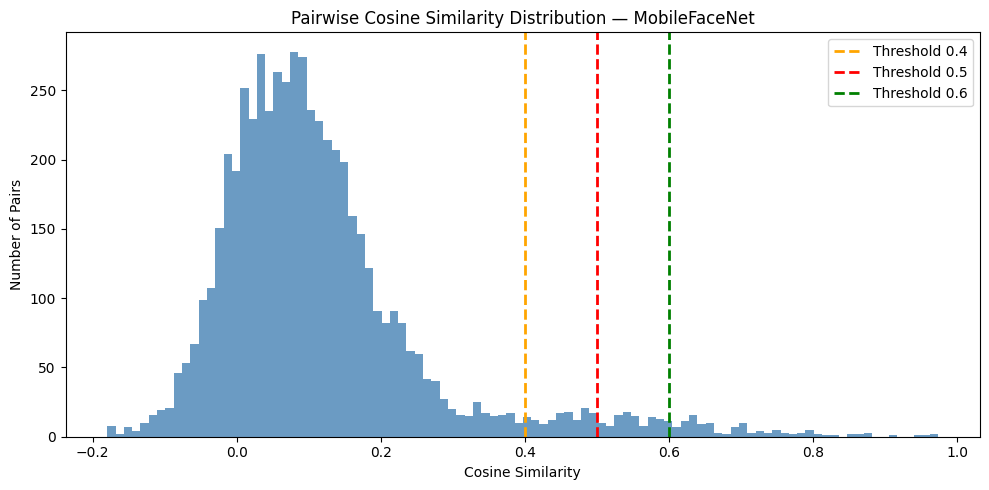

Total pairs      : 5671
Min similarity   : -0.1797
Max similarity   : 0.9737
Mean similarity  : 0.1183

Pairs above 0.4  : 361
Pairs above 0.5  : 232
Pairs above 0.6  : 124
Pairs above 0.7  : 52


In [14]:
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

# Use MobileFaceNet results (our target model for the app)
model_name = "MobileFaceNet"
data = all_results[model_name]
embs = np.array([d["embedding"] for d in data])
labels = [f"{d['image']}_f{d['face_index']}" for d in data]

# Compute ALL pairwise similarities
all_sims = []
for i, j in combinations(range(len(embs)), 2):
    sim = float(np.dot(embs[i], embs[j]))
    all_sims.append(sim)

all_sims = np.array(all_sims)

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(all_sims, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
plt.axvline(x=0.4, color='orange', linestyle='--', linewidth=2, label='Threshold 0.4')
plt.axvline(x=0.5, color='red',    linestyle='--', linewidth=2, label='Threshold 0.5')
plt.axvline(x=0.6, color='green',  linestyle='--', linewidth=2, label='Threshold 0.6')
plt.title(f'Pairwise Cosine Similarity Distribution — {model_name}')
plt.xlabel('Cosine Similarity')
plt.ylabel('Number of Pairs')
plt.legend()
plt.tight_layout()
plt.savefig('similarity_histogram.png', dpi=150)
plt.show()

print(f"Total pairs      : {len(all_sims)}")
print(f"Min similarity   : {all_sims.min():.4f}")
print(f"Max similarity   : {all_sims.max():.4f}")
print(f"Mean similarity  : {all_sims.mean():.4f}")
print(f"\nPairs above 0.4  : {(all_sims > 0.4).sum()}")
print(f"Pairs above 0.5  : {(all_sims > 0.5).sum()}")
print(f"Pairs above 0.6  : {(all_sims > 0.6).sum()}")
print(f"Pairs above 0.7  : {(all_sims > 0.7).sum()}")

In [15]:
import json

# Save ONLY MobileFaceNet embeddings
mobilefacenet_data = all_results["MobileFaceNet"]

serializable = [
    {
        "image": d["image"],
        "face_index": d["face_index"],
        "embedding": d["embedding"].tolist()
    }
    for d in mobilefacenet_data
]

with open("mobilefacenet_embeddings.json", "w") as f:
    json.dump(serializable, f)

print(f"Saved {len(serializable)} face embeddings to mobilefacenet_embeddings.json")
print(f"Saved at: {os.getcwd()}")

Saved 107 face embeddings to mobilefacenet_embeddings.json
Saved at: C:\Users\kvpra\OneDrive\Desktop\snapsquad-app\notebooks
